In [1]:
# ============================================================
#  JV Program – VLR México
#  Script 03: Figuras Capítulo 6 y 7 — Entregable 3
#  Requiere: dataset_WO_nivel.parquet y dataset_QC_eventos.parquet
#            generados por Script 01 (ETL)
#  Ejecutar DESPUÉS del Script 02 (Modelado)
# ============================================================

In [2]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings, os, glob
warnings.filterwarnings("ignore")
 
# Estilo corporativo
plt.rcParams.update({
    "font.family":     "Arial",
    "axes.titlesize":  12,
    "axes.labelsize":  10,
    "figure.dpi":      150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.alpha":      0.25,
    "grid.linestyle":  "--",
})
 
COLOR_CORP  = "#2E75B6"
COLOR_RED   = "#E05C2E"
COLOR_GREEN = "#1D9E75"
COLOR_DARK  = "#1a3a5c"
COLOR_AMBER = "#EF9F27"
PALETTE     = ["#1a3a5c","#2E75B6","#4A90C4","#5B9BD5","#78B4E0","#9ECAE8"]
 
os.makedirs("figuras_cap6", exist_ok=True)
 
def save(name, tight=True):
    path = f"figuras_cap6/{name}"
    plt.savefig(path, dpi=150, bbox_inches="tight" if tight else None,
                facecolor="white")
    plt.show()
    size = os.path.getsize(path) / 1024
    print(f"✅ {name}  ({size:.1f} KB)")
 
print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# ── CELDA 2: Cargar datasets ──────────────────────────────────────────────────
import os

# FIX: la versión original llamaba pd.read_parquet() directamente sin
# verificar que los archivos existan. Si este notebook se ejecuta en una
# sesión nueva sin haber corrido antes 01_ETL_JVProgram.ipynb, fallaba con
# un FileNotFoundError poco claro y sin indicar al usuario qué hacer.
RUTA_WO = "dataset_WO_nivel.parquet"
RUTA_QC = "dataset_QC_eventos.parquet"

faltantes = [r for r in (RUTA_WO, RUTA_QC) if not os.path.exists(r)]
if faltantes:
    raise FileNotFoundError(
        f"No se encontraron los siguientes archivos: {faltantes}\n"
        f"Carpeta actual: {os.getcwd()}\n"
        f"Ejecuta primero 01_ETL_JVProgram.ipynb para generarlos, o copia "
        f"los .parquet a esta carpeta."
    )

dw = pd.read_parquet(RUTA_WO)
df_qc = pd.read_parquet(RUTA_QC)

# Asegurar tipos de fecha
for df, cols in [
    (dw,    ["FECHA_INI_CORTE","FECHA_FIN_CORTE","FECHA_INI_COSTURA",
              "FECHA_FIN_COSTURA","FECHA_EMBARQUE","SCHEDULE_DATE"]),
    (df_qc, ["FECHA_QC"]),
]:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# Asegurar FECHA_SEMANA
def yyww_to_date(val):
    try:
        num = str(val).replace("WEEK","").strip().zfill(4)
        return pd.Timestamp.fromisocalendar(int("20"+num[:2]), int(num[2:]), 1)
    except:
        return pd.NaT

if "FECHA_SEMANA" not in dw.columns:
    dw["FECHA_SEMANA"] = dw["PRODUCTION_WEEK"].apply(yyww_to_date)

print(f"✅ Datasets cargados: {len(dw):,} WO · {len(df_qc):,} eventos QC")


✅ Datasets cargados: 44,485 WO · 44,057 eventos QC


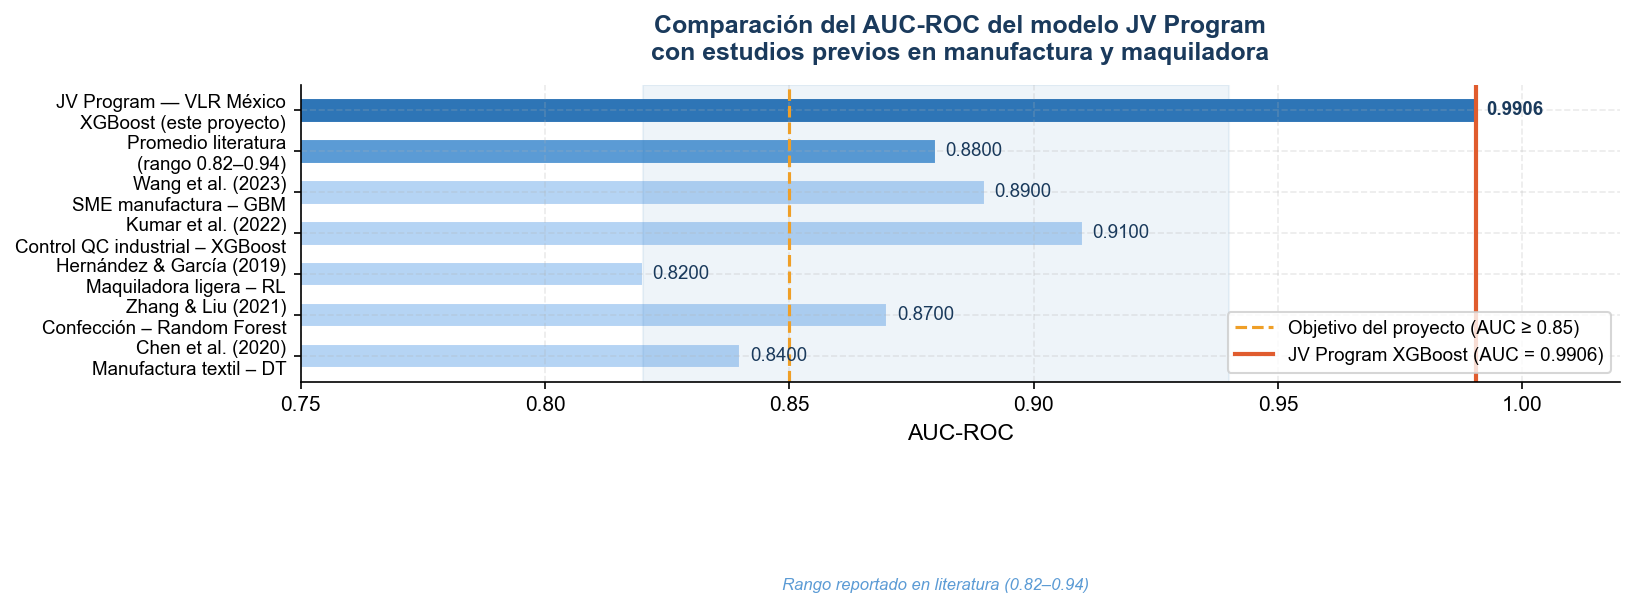

✅ figura23_comparacion_literatura.png  (134.0 KB)


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 23 — Comparación AUC-ROC con literatura
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 3 ───────────────────────────────────────────────────────────────────
AUC_MODELO = 0.9906   # ← reemplaza con tu valor real si difiere
 
referencias = [
    ("Chen et al. (2020)\nManufactura textil – DT",         0.84),
    ("Zhang & Liu (2021)\nConfección – Random Forest",       0.87),
    ("Hernández & García (2019)\nMaquiladora ligera – RL",   0.82),
    ("Kumar et al. (2022)\nControl QC industrial – XGBoost", 0.91),
    ("Wang et al. (2023)\nSME manufactura – GBM",            0.89),
    ("Promedio literatura\n(rango 0.82–0.94)",               0.88),
    ("JV Program — VLR México\nXGBoost (este proyecto)",     AUC_MODELO),
]
etiquetas = [r[0] for r in referencias]
valores   = [r[1] for r in referencias]
colores   = [COLOR_CORP if "JV Program" in e else
             ("#5B9BD5" if "Promedio" in e else "#B5D4F4")
             for e in etiquetas]
 
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(etiquetas, valores, color=colores, edgecolor="white",
               height=0.6)
ax.set_xlim(0.75, 1.02)
ax.axvline(0.85, color=COLOR_AMBER, lw=1.5, ls="--",
           label="Objetivo del proyecto (AUC ≥ 0.85)")
ax.axvline(AUC_MODELO, color=COLOR_RED, lw=2, ls="-",
           label=f"JV Program XGBoost (AUC = {AUC_MODELO})")
 
for bar, val in zip(bars, valores):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9,
            fontweight="bold" if val == AUC_MODELO else "normal",
            color=COLOR_DARK)
 
ax.set_xlabel("AUC-ROC", fontsize=11)
ax.set_title("Comparación del AUC-ROC del modelo JV Program\n"
             "con estudios previos en manufactura y maquiladora",
             fontsize=12, fontweight="bold", color=COLOR_DARK, pad=12)
ax.legend(fontsize=9, loc="lower right")
ax.tick_params(axis="y", labelsize=9)
 
# Shaded rango literatura
ax.axvspan(0.82, 0.94, alpha=0.08, color=COLOR_CORP,
           label="Rango literatura (0.82–0.94)")
ax.text(0.88, -0.7, "Rango reportado en literatura (0.82–0.94)",
        ha="center", fontsize=8, color="#5B9BD5", style="italic",
        transform=ax.get_xaxis_transform())
 
plt.tight_layout()
save("figura23_comparacion_literatura.png")

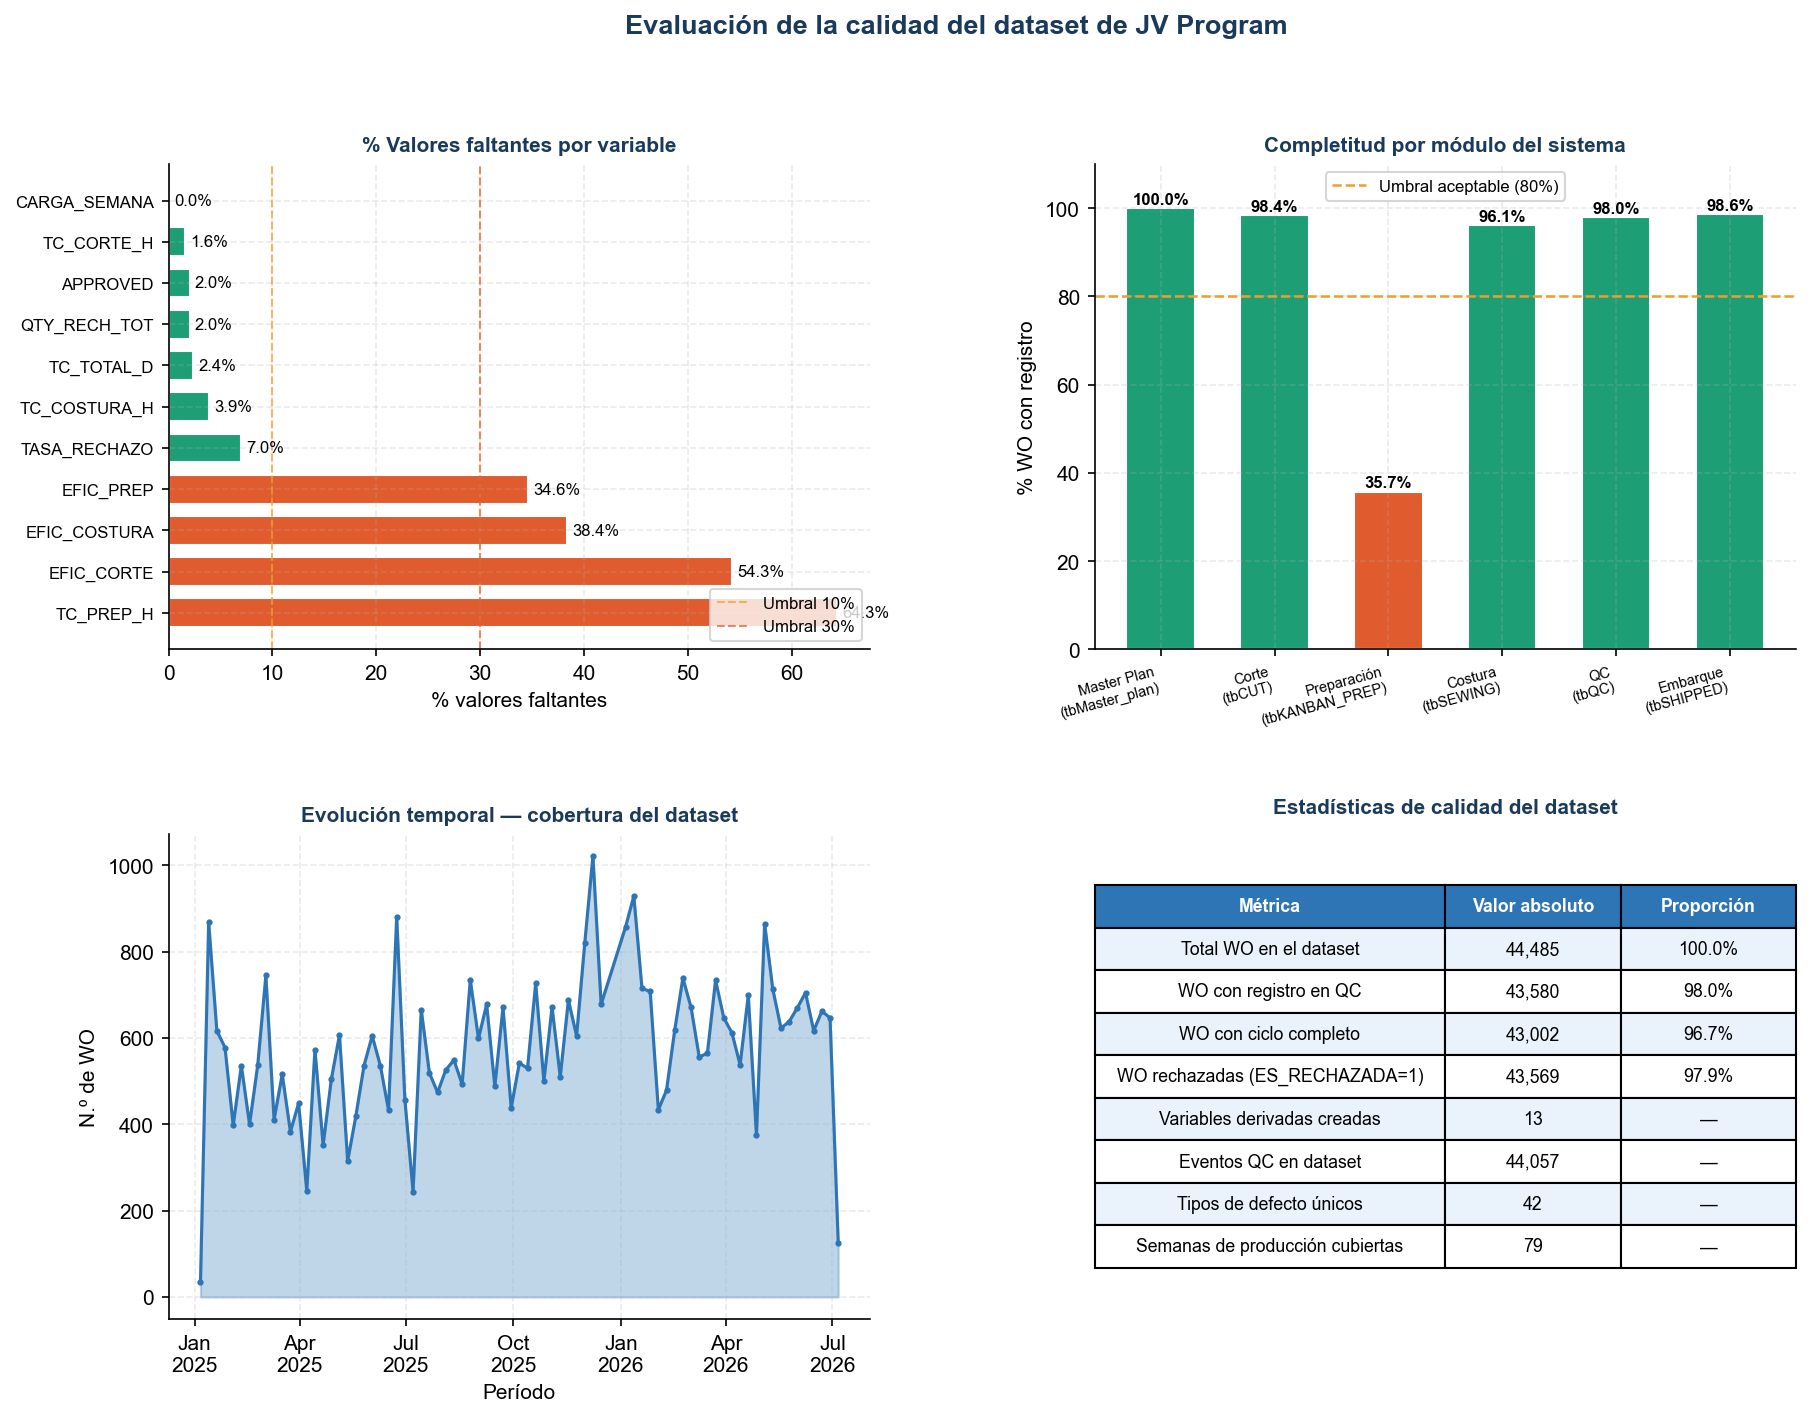

✅ figura24_calidad_dataset.png  (300.1 KB)


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 24 — Calidad del dataset (4 paneles)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 4 ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Evaluación de la calidad del dataset de JV Program",
             fontsize=13, fontweight="bold", color=COLOR_DARK, y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
 
# ── Panel 1: Mapa de calor de nulos ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cols_analisis = ["TC_TOTAL_D","TC_CORTE_H","TC_PREP_H","TC_COSTURA_H",
                 "TASA_RECHAZO","EFIC_CORTE","EFIC_PREP","EFIC_COSTURA",
                 "APPROVED","QTY_RECH_TOT","CARGA_SEMANA"]
cols_existentes = [c for c in cols_analisis if c in dw.columns]
pct_nulos = dw[cols_existentes].isna().mean() * 100
pct_nulos = pct_nulos.sort_values(ascending=False)
 
colors_null = [COLOR_RED if v > 30 else COLOR_AMBER if v > 10
               else COLOR_GREEN for v in pct_nulos]
bars1 = ax1.barh(pct_nulos.index, pct_nulos.values,
                 color=colors_null, edgecolor="white", height=0.7)
ax1.axvline(10, color=COLOR_AMBER, lw=1, ls="--", alpha=0.7,
            label="Umbral 10%")
ax1.axvline(30, color=COLOR_RED, lw=1, ls="--", alpha=0.7,
            label="Umbral 30%")
for bar, val in zip(bars1, pct_nulos.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=8)
ax1.set_xlabel("% valores faltantes")
ax1.set_title("% Valores faltantes por variable", fontsize=10,
              fontweight="bold", color=COLOR_DARK)
ax1.legend(fontsize=8, loc="lower right")
ax1.tick_params(axis="y", labelsize=8)
 
# ── Panel 2: Completitud por módulo ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
modulos = ["Master Plan\n(tbMaster_plan)","Corte\n(tbCUT)","Preparación\n(tbKANBAN_PREP)",
           "Costura\n(tbSEWING)","QC\n(tbQC)","Embarque\n(tbSHIPPED)"]
 
completitud_cols = {
    "Master Plan\n(tbMaster_plan)": "ITEM",
    "Corte\n(tbCUT)": "TC_CORTE_H",
    "Preparación\n(tbKANBAN_PREP)": "TC_PREP_H",
    "Costura\n(tbSEWING)": "TC_COSTURA_H",
    "QC\n(tbQC)": "APPROVED",
    "Embarque\n(tbSHIPPED)": "FECHA_EMBARQUE",
}
pcts_mod = []
for mod, col in completitud_cols.items():
    if col in dw.columns:
        pct = dw[col].notna().mean() * 100
    else:
        pct = 0
    pcts_mod.append(pct)
 
colors_mod = [COLOR_GREEN if p > 80 else COLOR_AMBER if p > 50
              else COLOR_RED for p in pcts_mod]
bars2 = ax2.bar(range(len(modulos)), pcts_mod, color=colors_mod,
                edgecolor="white", width=0.6)
ax2.set_xticks(range(len(modulos)))
ax2.set_xticklabels(modulos, fontsize=7, rotation=15, ha="right")
ax2.set_ylim(0, 110)
ax2.axhline(80, color=COLOR_AMBER, lw=1.2, ls="--",
            label="Umbral aceptable (80%)")
ax2.set_ylabel("% WO con registro")
ax2.set_title("Completitud por módulo del sistema", fontsize=10,
              fontweight="bold", color=COLOR_DARK)
for bar, val in zip(bars2, pcts_mod):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax2.legend(fontsize=8)
 
# ── Panel 3: Evolución temporal del volumen de registros ─────────────────────
ax3 = fig.add_subplot(gs[1, 0])
semana_vol = (dw.groupby("FECHA_SEMANA")["WO"]
               .count().reset_index()
               .sort_values("FECHA_SEMANA")
               .dropna(subset=["FECHA_SEMANA"]))
ax3.fill_between(semana_vol["FECHA_SEMANA"], semana_vol["WO"],
                 alpha=0.3, color=COLOR_CORP)
ax3.plot(semana_vol["FECHA_SEMANA"], semana_vol["WO"],
         color=COLOR_CORP, lw=1.5, marker="o", markersize=2)
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax3.set_ylabel("N.º de WO")
ax3.set_title("Evolución temporal — cobertura del dataset", fontsize=10,
              fontweight="bold", color=COLOR_DARK)
ax3.set_xlabel("Período")
 
# ── Panel 4: Tabla resumen de calidad ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
 
n_total    = len(dw)
n_con_qc   = dw["APPROVED"].notna().sum() if "APPROVED" in dw.columns else 0
n_completo = dw[["TC_TOTAL_D","APPROVED"]].dropna().shape[0] \
             if "TC_TOTAL_D" in dw.columns and "APPROVED" in dw.columns else 0
n_rechazadas = (dw["ES_RECHAZADA"] == 1).sum() if "ES_RECHAZADA" in dw.columns else 0
 
resumen_data = [
    ["Total WO en el dataset",            f"{n_total:,}",             "100.0%"],
    ["WO con registro en QC",             f"{n_con_qc:,}",            f"{n_con_qc/n_total*100:.1f}%"],
    ["WO con ciclo completo",             f"{n_completo:,}",          f"{n_completo/n_total*100:.1f}%"],
    ["WO rechazadas (ES_RECHAZADA=1)",    f"{n_rechazadas:,}",        f"{n_rechazadas/n_total*100:.1f}%"],
    ["Variables derivadas creadas",       "13",                       "—"],
    ["Eventos QC en dataset",             f"{len(df_qc):,}",          "—"],
    ["Tipos de defecto únicos",           f"{df_qc['DESCRIPTION'].nunique() if 'DESCRIPTION' in df_qc.columns else 'N/A'}", "—"],
    ["Semanas de producción cubiertas",   f"{dw['SEMANA_NUM'].nunique() if 'SEMANA_NUM' in dw.columns else 'N/A'}", "—"],
]
tbl = ax4.table(
    cellText   = resumen_data,
    colLabels  = ["Métrica", "Valor absoluto", "Proporción"],
    cellLoc    = "center",
    loc        = "center",
    colWidths  = [0.5, 0.25, 0.25],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLOR_CORP)
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2:
        cell.set_facecolor("#EAF3FB")
ax4.set_title("Estadísticas de calidad del dataset", fontsize=10,
              fontweight="bold", color=COLOR_DARK, pad=10)
 
save("figura24_calidad_dataset.png")

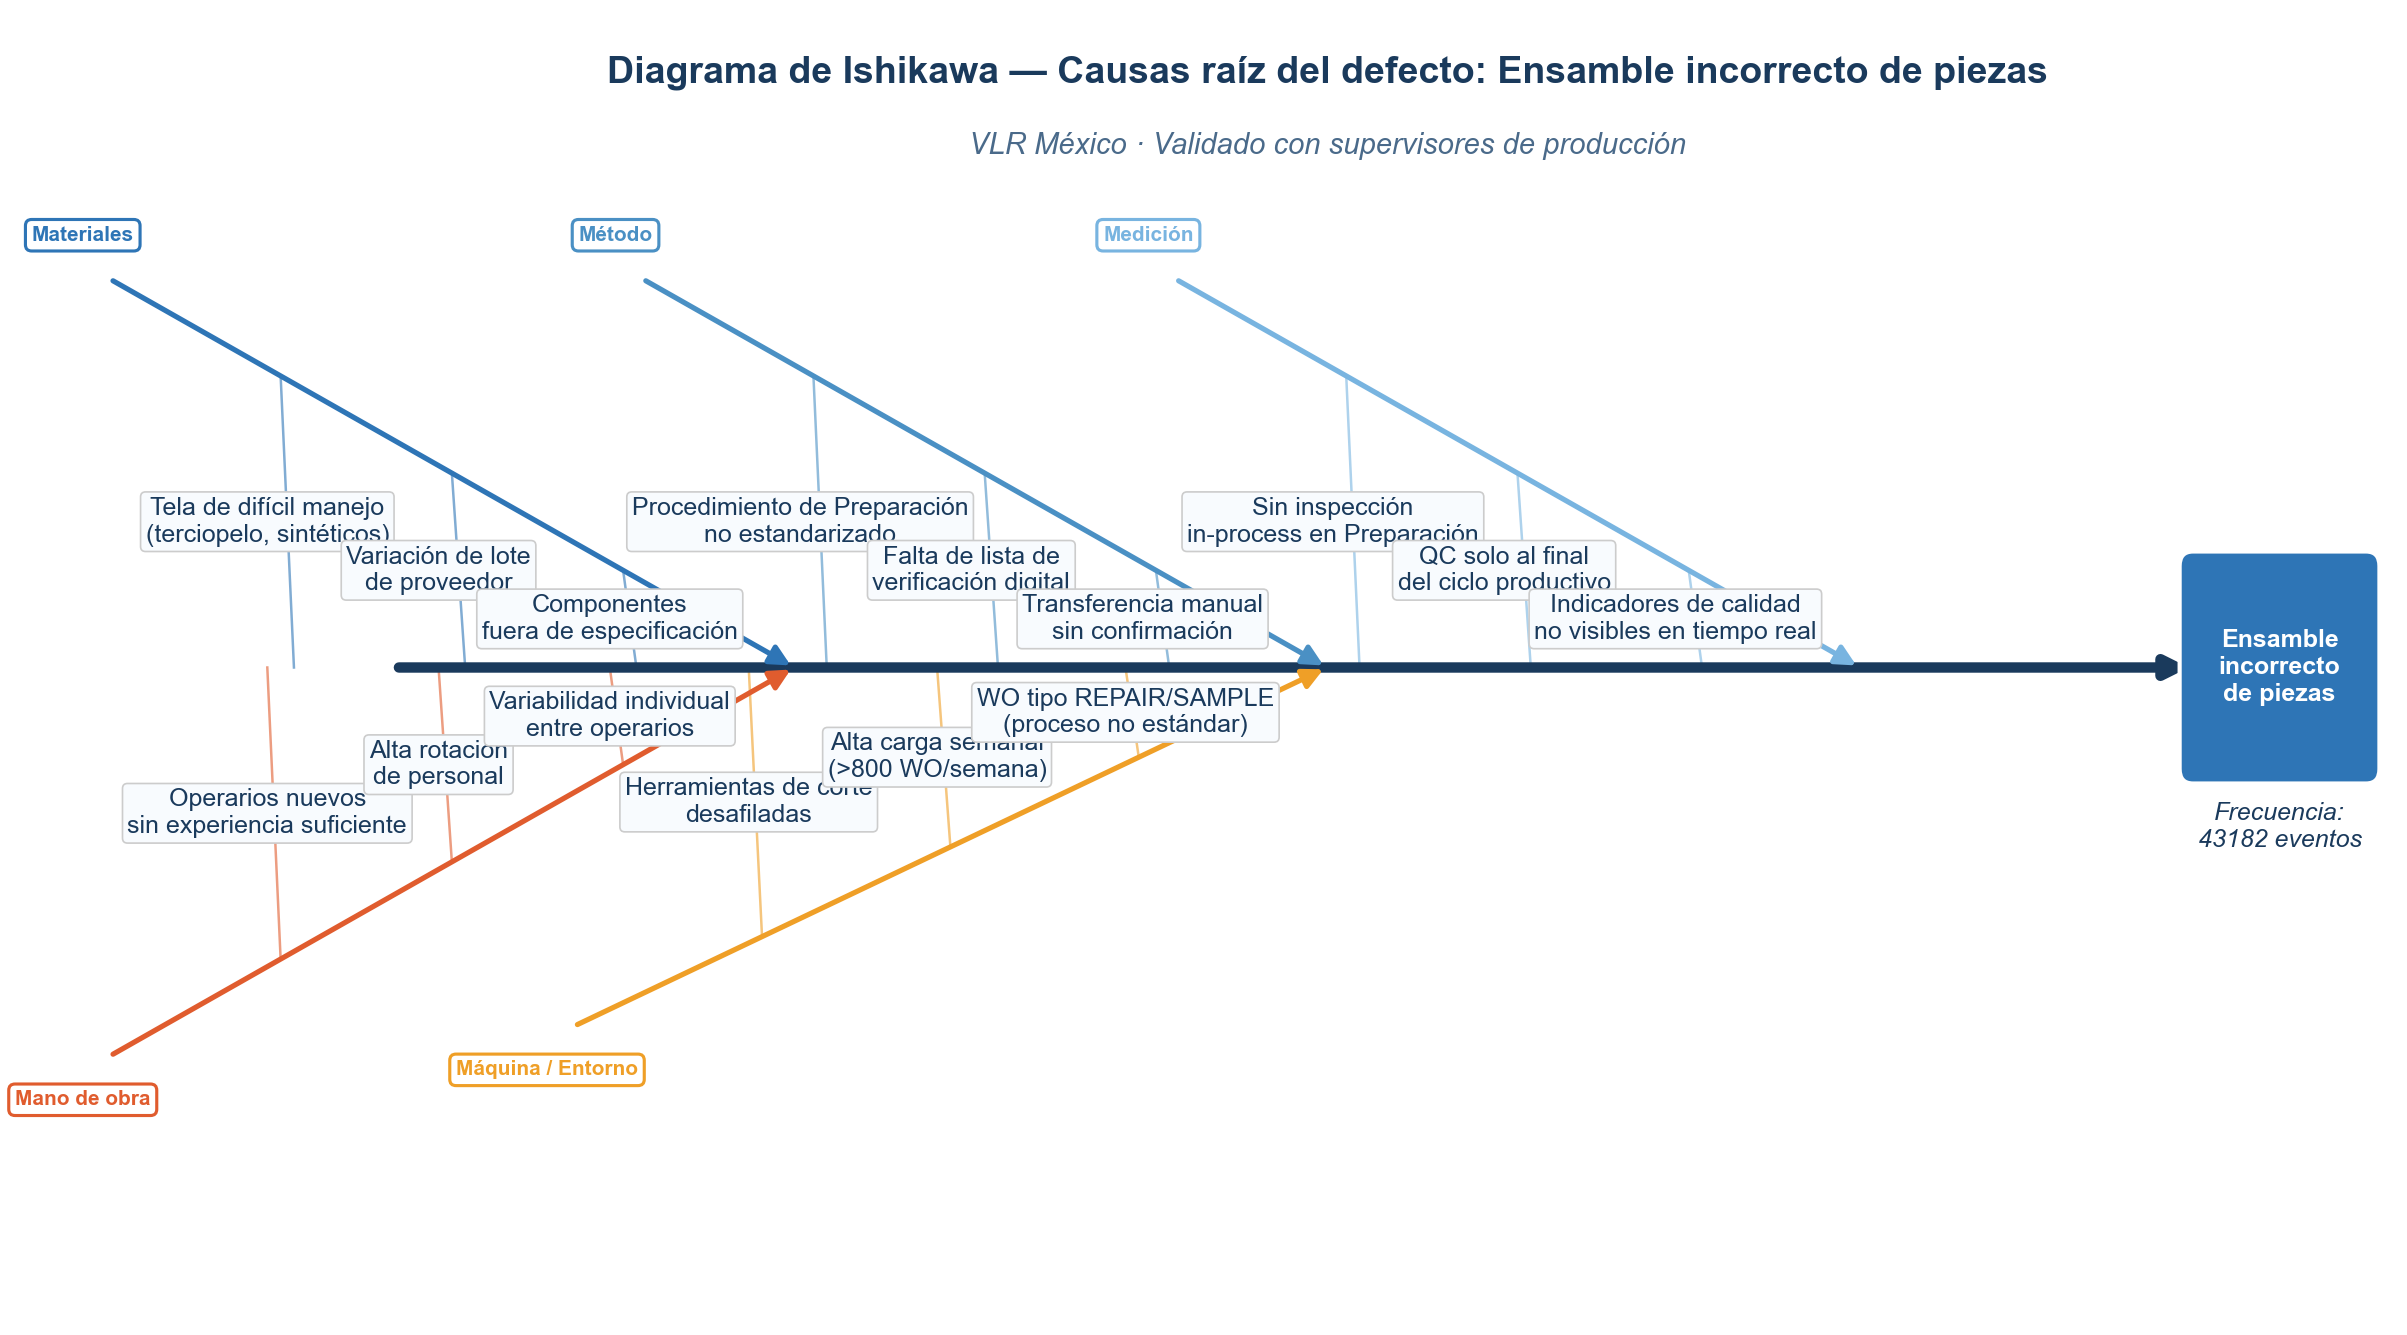

✅ figura25_ishikawa_ensamble.png  (299.0 KB)


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 25 — Diagrama de Ishikawa (causa-efecto)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 5 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")
ax.set_facecolor("white")
 
# Espina central
ax.annotate("", xy=(14.5, 4.5), xytext=(1, 4.5),
            arrowprops=dict(arrowstyle="-|>", color=COLOR_DARK,
                            lw=5, mutation_scale=20))
 
# Efecto (cabeza)
cabeza = FancyBboxPatch((14.5, 3.8), 1.3, 1.4,
                         boxstyle="round,pad=0.1",
                         facecolor=COLOR_CORP, edgecolor="white",
                         linewidth=2, zorder=4)
ax.add_patch(cabeza)
ax.text(15.15, 4.5, "Ensamble\nincorrecto\nde piezas",
        ha="center", va="center", fontsize=12,
        color="white", fontweight="bold", zorder=5)
 
# Título
ax.text(8, 8.6, "Diagrama de Ishikawa — Causas raíz del defecto: Ensamble incorrecto de piezas",
        ha="center", va="center", fontsize=18,
        fontweight="bold", color=COLOR_DARK)
ax.text(8, 8.1, "VLR México · Validado con supervisores de producción",
        ha="center", va="center", fontsize=14,
        color="#4a6a8a", style="italic")
 
# Definición de las 5 ramas (angle, x_origen, y_origen, label, causas)
ramas = [
    # Ramas superiores
    (50,  4,   4.5, "Materiales",
     ["Tela de difícil manejo\n(terciopelo, sintéticos)",
      "Variación de lote\nde proveedor",
      "Componentes\nfuera de especificación"]),
    (50,  8,   4.5, "Método",
     ["Procedimiento de Preparación\nno estandarizado",
      "Falta de lista de\nverificación digital",
      "Transferencia manual\nsin confirmación"]),
    (50,  12,  4.5, "Medición",
     ["Sin inspección\nin-process en Preparación",
      "QC solo al final\ndel ciclo productivo",
      "Indicadores de calidad\nno visibles en tiempo real"]),
    # Ramas inferiores
    (-50, 4,   4.5, "Mano de obra",
     ["Operarios nuevos\nsin experiencia suficiente",
      "Alta rotación\nde personal",
      "Variabilidad individual\nentre operarios"]),
    (-45, 8,   4.5, "Máquina / Entorno",
     ["Herramientas de corte\ndesafiladas",
      "Alta carga semanal\n(>800 WO/semana)",
      "WO tipo REPAIR/SAMPLE\n(proceso no estándar)"]),
]
 
BRANCH_COLORS = [COLOR_CORP, "#4A90C4", "#78B4E0",
                 COLOR_RED,  COLOR_AMBER]
 
for (angle, x0, y0, label, causas), color in zip(ramas, BRANCH_COLORS):
    sign = 1 if angle > 0 else -1
    rad  = np.radians(abs(angle))
    dx   = 8 * np.cos(rad)
    dy   = sign * 3.5 * np.sin(rad)
 
    # Rama principal
    ax.annotate("", xy=(x0, y0), xytext=(x0 - dx, y0 + dy),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=2.5, mutation_scale=20))
 
    # Etiqueta de la rama
    ax.text(x0 - dx - 0.2, y0 + dy + sign*0.3, label,
            ha="center", va="center", fontsize=10,
            fontweight="bold", color=color,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=color, linewidth=1.5))
 
    # Sub-causas
    for j, causa in enumerate(causas):
        frac   = (j + 1) / (len(causas) + 1)
        xc     = (x0 - dx) + frac * dx
        yc     = (y0 + dy) - frac * dy
        yc_end = y0 + (yc - y0) * 0.3
 
        ax.plot([xc, xc + sign*0.1], [yc, y0],
                color=color, lw=1.2, alpha=0.6)
        ax.text(xc + sign*(-0.1 if angle > 0 else 0.1),
                (yc + y0) / 2,
                causa, ha="center", va="center",
                fontsize=12, color=COLOR_DARK,
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="#F8FBFE",
                          edgecolor="#cccccc", linewidth=0.8))
 
# Frecuencia de evidencia basada en datos
ax.text(15.15, 3.4,
        f"Frecuencia:\n{df_qc['DESCRIPTION'].value_counts().iloc[0] if 'DESCRIPTION' in df_qc.columns else 'N/A'} eventos",
        ha="center", va="center", fontsize=12, color=COLOR_DARK,
        style="italic")
 
plt.tight_layout()
save("figura25_ishikawa_ensamble.png")

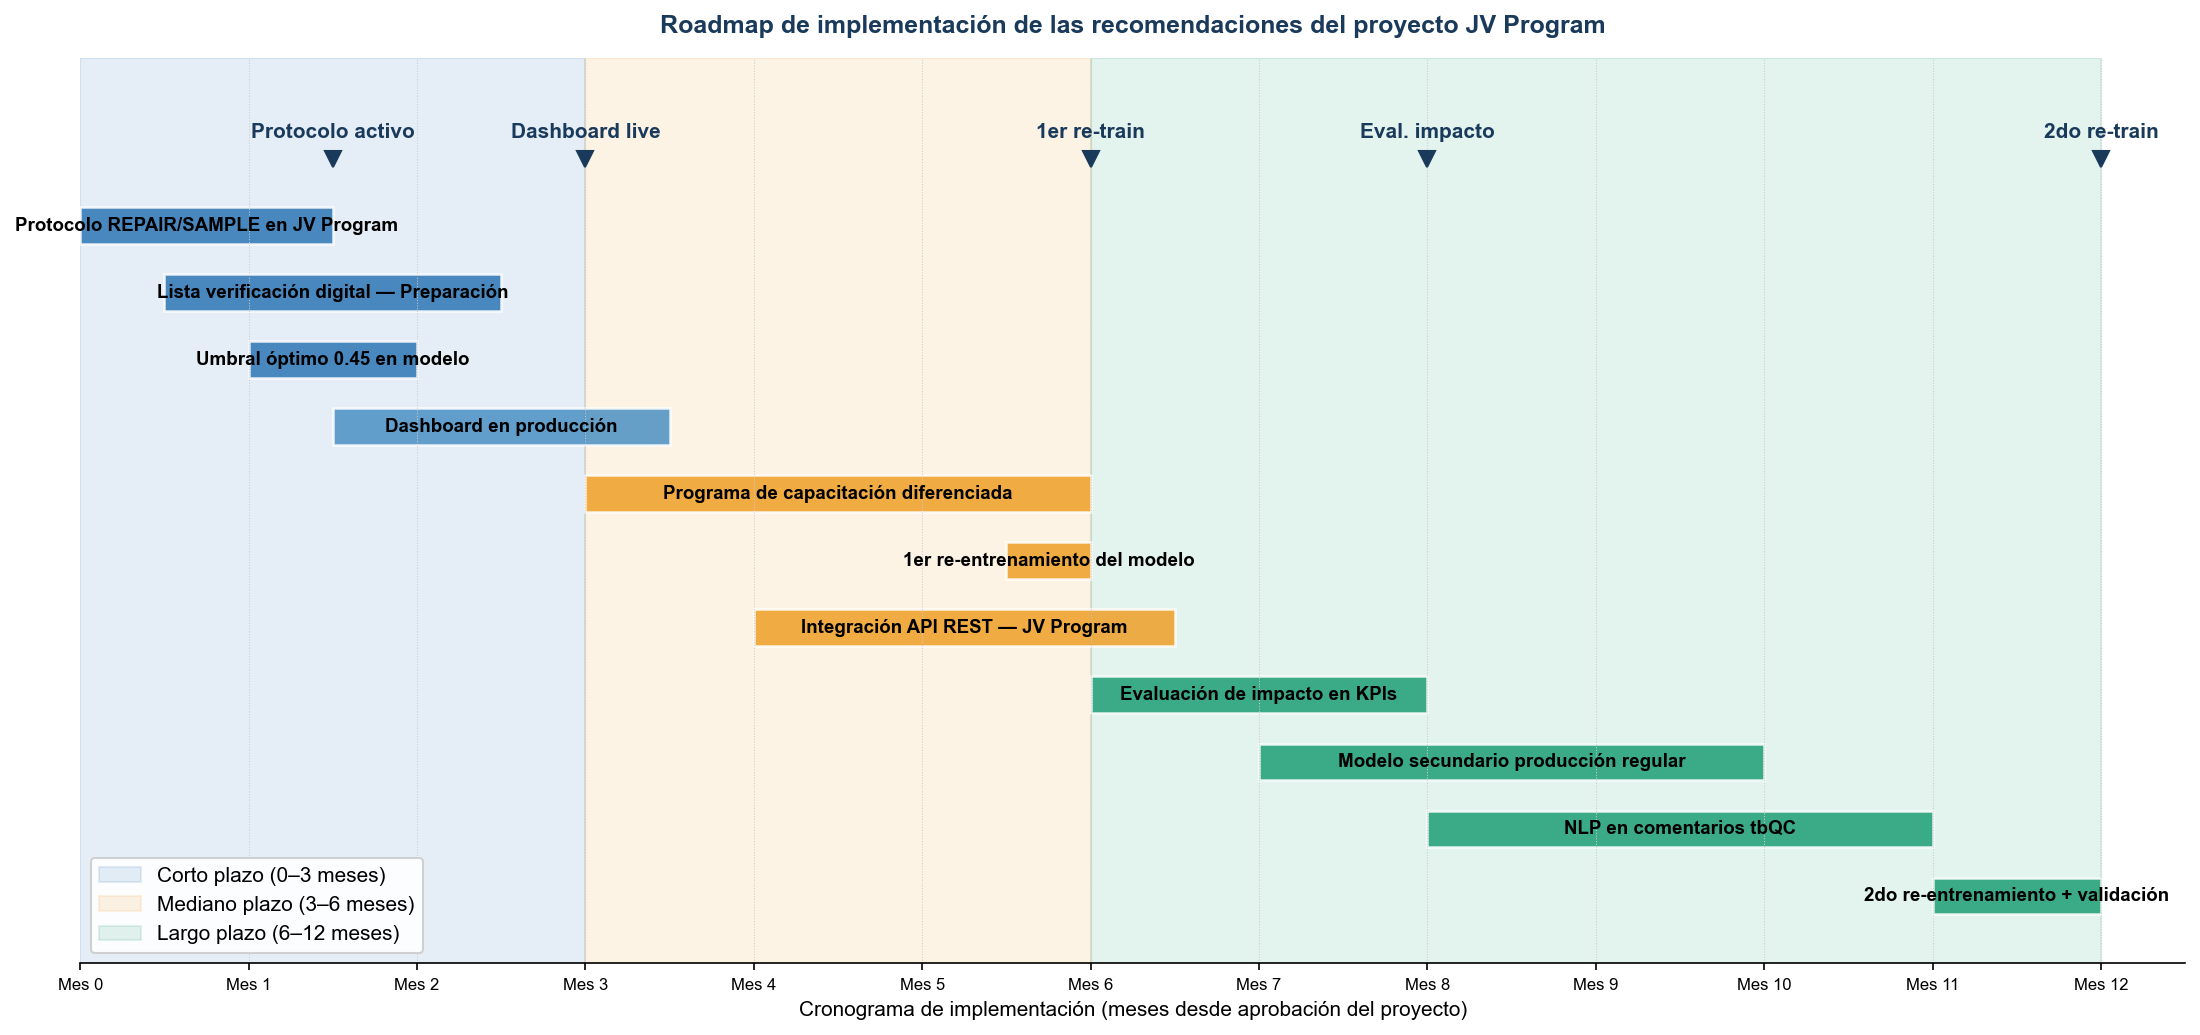

✅ figura26_roadmap_implementacion.png  (192.0 KB)


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 26 — Roadmap de implementación (Gantt)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 6 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 7))
ax.set_facecolor("white")
 
# Tareas: (nombre, inicio_mes, duracion_meses, capa, color)
tareas = [
    # Corto plazo (0–3)
    ("Protocolo REPAIR/SAMPLE en JV Program",   0, 1.5, "Corto",  COLOR_CORP),
    ("Lista verificación digital — Preparación",0.5, 2, "Corto",  COLOR_CORP),
    ("Umbral óptimo 0.45 en modelo",            1, 1,   "Corto",  COLOR_CORP),
    ("Dashboard en producción",                 1.5, 2, "Corto",  "#4A90C4"),
    # Mediano plazo (3–6)
    ("Programa de capacitación diferenciada",   3, 3,   "Medio",  COLOR_AMBER),
    ("1er re-entrenamiento del modelo",         5.5, 0.5, "Medio",COLOR_AMBER),
    ("Integración API REST — JV Program",       4, 2.5, "Medio",  "#EF9F27"),
    # Largo plazo (6–12)
    ("Evaluación de impacto en KPIs",           6, 2,   "Largo",  COLOR_GREEN),
    ("Modelo secundario producción regular",    7, 3,   "Largo",  COLOR_GREEN),
    ("NLP en comentarios tbQC",                 8, 3,   "Largo",  "#1D9E75"),
    ("2do re-entrenamiento + validación",       11,1,   "Largo",  COLOR_GREEN),
]
 
n = len(tareas)
y_positions = list(range(n, 0, -1))
capa_color = {"Corto": "#EAF3FB", "Medio": "#FEF3E2", "Largo": "#EAF3DE"}
 
# Franjas de fondo por capa
ax.axvspan(0,  3,  alpha=0.12, color=COLOR_CORP,  label="Corto plazo (0–3 meses)")
ax.axvspan(3,  6,  alpha=0.12, color=COLOR_AMBER, label="Mediano plazo (3–6 meses)")
ax.axvspan(6,  12, alpha=0.12, color=COLOR_GREEN, label="Largo plazo (6–12 meses)")
 
for i, (nombre, inicio, dur, capa, color) in enumerate(tareas):
    y = y_positions[i]
    ax.barh(y, dur, left=inicio, height=0.55,
            color=color, alpha=0.85, edgecolor="white",
            linewidth=1.2)
    ax.text(inicio + dur/2, y, nombre,
            ha="center", va="center",
            fontsize=9, color="black", fontweight="bold")
 
# Líneas de mes
for m in range(1, 13):
    ax.axvline(m, color="#cccccc", lw=0.5, ls=":")
 
# Hitos
hitos = [(1.5, "Protocolo activo"), (3, "Dashboard live"),
         (6, "1er re-train"), (8, "Eval. impacto"), (12, "2do re-train")]
for mes, label in hitos:
    ax.plot(mes, n + 1, "v", color=COLOR_DARK, markersize=8, zorder=5)
    ax.text(mes, n + 1.3, label, ha="center", fontsize=10,
            color=COLOR_DARK, fontweight="bold")
 
ax.set_xlim(0, 12.5)
ax.set_ylim(0, n + 2.5)
ax.set_yticks([])
ax.set_xticks(range(0, 13))
ax.set_xticklabels([f"Mes {m}" for m in range(0, 13)], fontsize=8)
ax.set_xlabel("Cronograma de implementación (meses desde aprobación del proyecto)",
              fontsize=10)
ax.set_title("Roadmap de implementación de las recomendaciones del proyecto JV Program",
             fontsize=12, fontweight="bold", color=COLOR_DARK, pad=12)
ax.legend(loc="lower left", fontsize=10, framealpha=0.9)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
 
plt.tight_layout()
save("figura26_roadmap_implementacion.png")
 

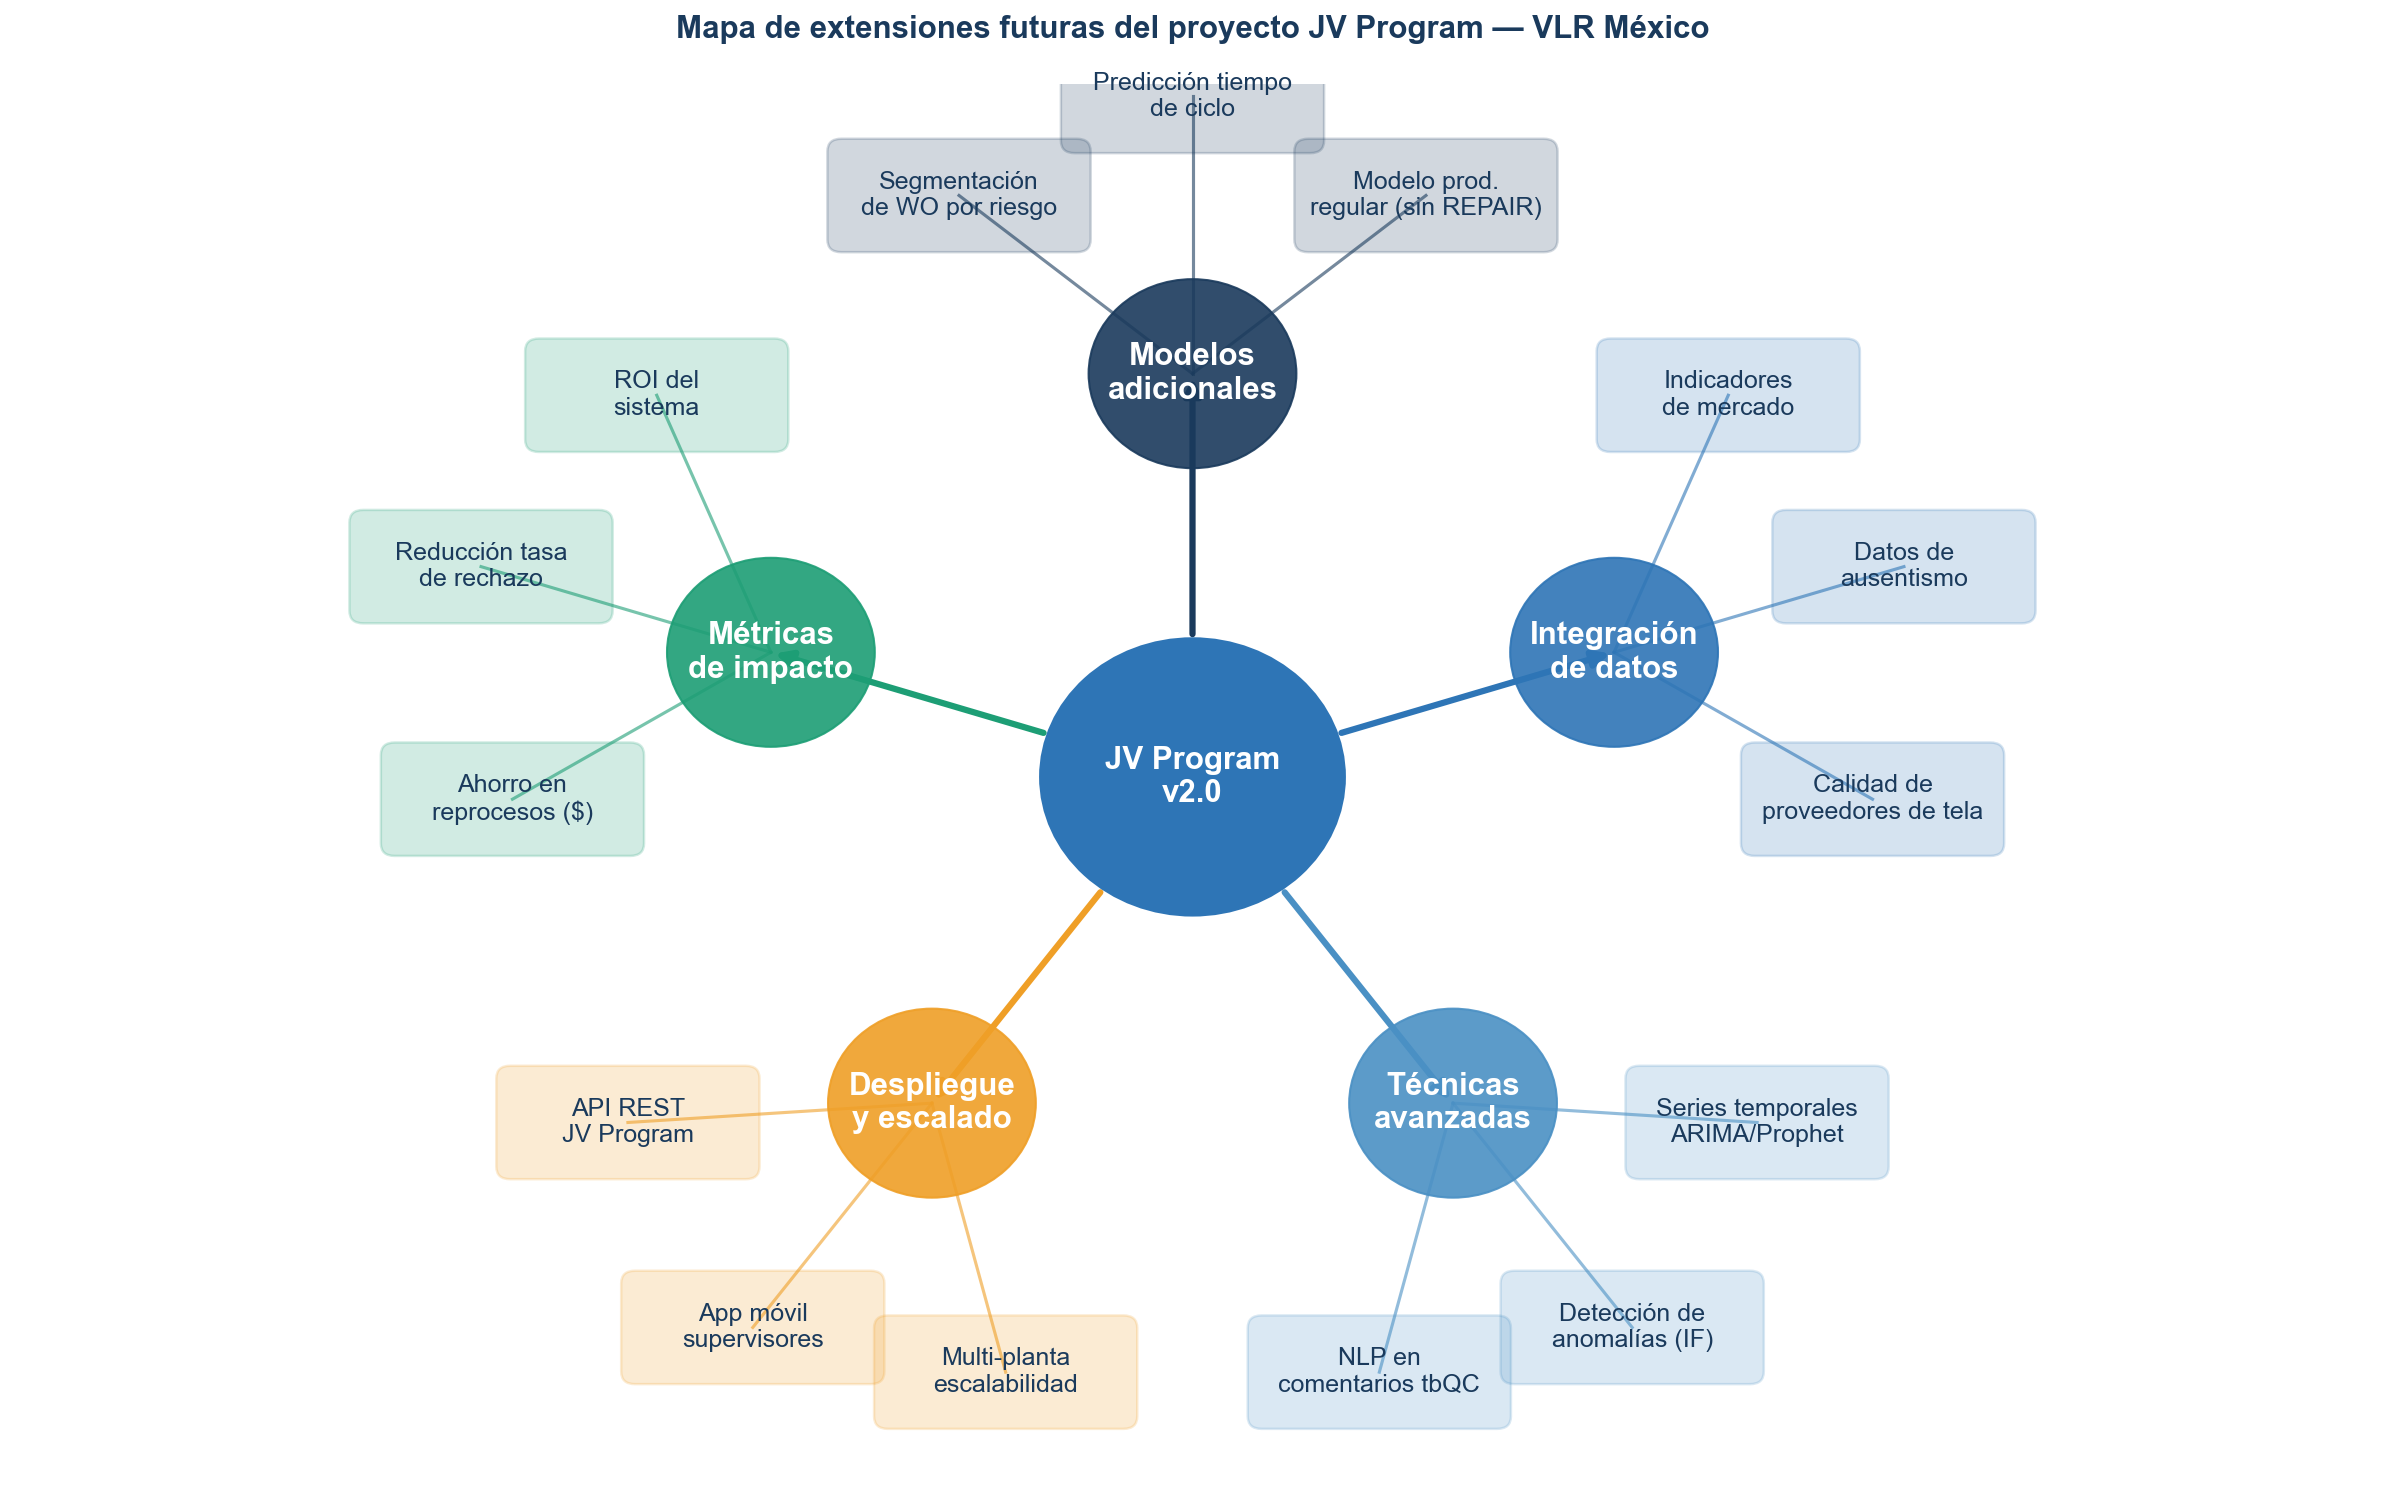

✅ figura27_mapa_extensiones.png  (306.9 KB)


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 27 — Mapa mental de extensiones futuras
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 7 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(-8.5, 8.5)
ax.set_ylim(-5.5, 5.5)
ax.axis("off")
ax.set_facecolor("white")
 
# Nodo central
centro = plt.Circle((0, 0), 1.1, color=COLOR_CORP, zorder=4)
ax.add_patch(centro)
ax.text(0, 0, "JV Program\nv2.0", ha="center", va="center",
        fontsize=15, fontweight="bold", color="white", zorder=5)
 
# Ramas principales: (ángulo, etiqueta, color, sub-nodos)
ramas_mm = [
    (90,  "Modelos\nadicionales",   "#1a3a5c",
     ["Modelo prod.\nregular (sin REPAIR)","Predicción tiempo\nde ciclo","Segmentación\nde WO por riesgo"]),
    (18,  "Integración\nde datos",   COLOR_CORP,
     ["Calidad de\nproveedores de tela","Datos de\nausentismo","Indicadores\nde mercado"]),
    (-54, "Técnicas\navanzadas",     "#4A90C4",
     ["NLP en\ncomentarios tbQC","Detección de\nanomalías (IF)","Series temporales\nARIMA/Prophet"]),
    (-126,"Despliegue\ny escalado",   COLOR_AMBER,
     ["API REST\nJV Program","App móvil\nsupervisores","Multi-planta\nescalabilidad"]),
    (162, "Métricas\nde impacto",    COLOR_GREEN,
     ["ROI del\nsistema","Reducción tasa\nde rechazo","Ahorro en\nreprocesos ($)"]),
]
 
for angulo, label, color, subnodos in ramas_mm:
    rad = np.radians(angulo)
    x1  = 1.1  * np.cos(rad)
    y1  = 1.1  * np.sin(rad)
    x2  = 3.2  * np.cos(rad)
    y2  = 3.2  * np.sin(rad)
 
    # Línea rama principal
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=3, mutation_scale=16))
    # Nodo rama principal
    circ = plt.Circle((x2, y2), 0.75, color=color, zorder=4, alpha=0.9)
    ax.add_patch(circ)
    ax.text(x2, y2, label, ha="center", va="center",
            fontsize=15, fontweight="bold", color="white", zorder=5)
 
    # Sub-nodos
    spread = [-50, 0, 50]
    for j, (sub, ang_off) in enumerate(zip(subnodos, spread)):
        rad2 = np.radians(angulo + ang_off)
        x3   = (3.2 + 2.2) * np.cos(rad2) + (x2 - 3.2*np.cos(rad)) * 0
        x3   = x2 + 2.2 * np.cos(rad2)
        y3   = y2 + 2.2 * np.sin(rad2)
 
        ax.plot([x2, x3], [y2, y3], color=color, lw=1.5, alpha=0.6, zorder=3)
        sub_rect = FancyBboxPatch((x3-0.85, y3-0.35), 1.7, 0.7,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, alpha=0.2,
                                   edgecolor=color, linewidth=1.2, zorder=4)
        ax.add_patch(sub_rect)
        ax.text(x3, y3, sub, ha="center", va="center",
                fontsize=12, color=COLOR_DARK, zorder=5)
 
ax.set_title("Mapa de extensiones futuras del proyecto JV Program — VLR México",
             fontsize=15, fontweight="bold", color=COLOR_DARK, pad=22)
plt.tight_layout()
save("figura27_mapa_extensiones.png")
 

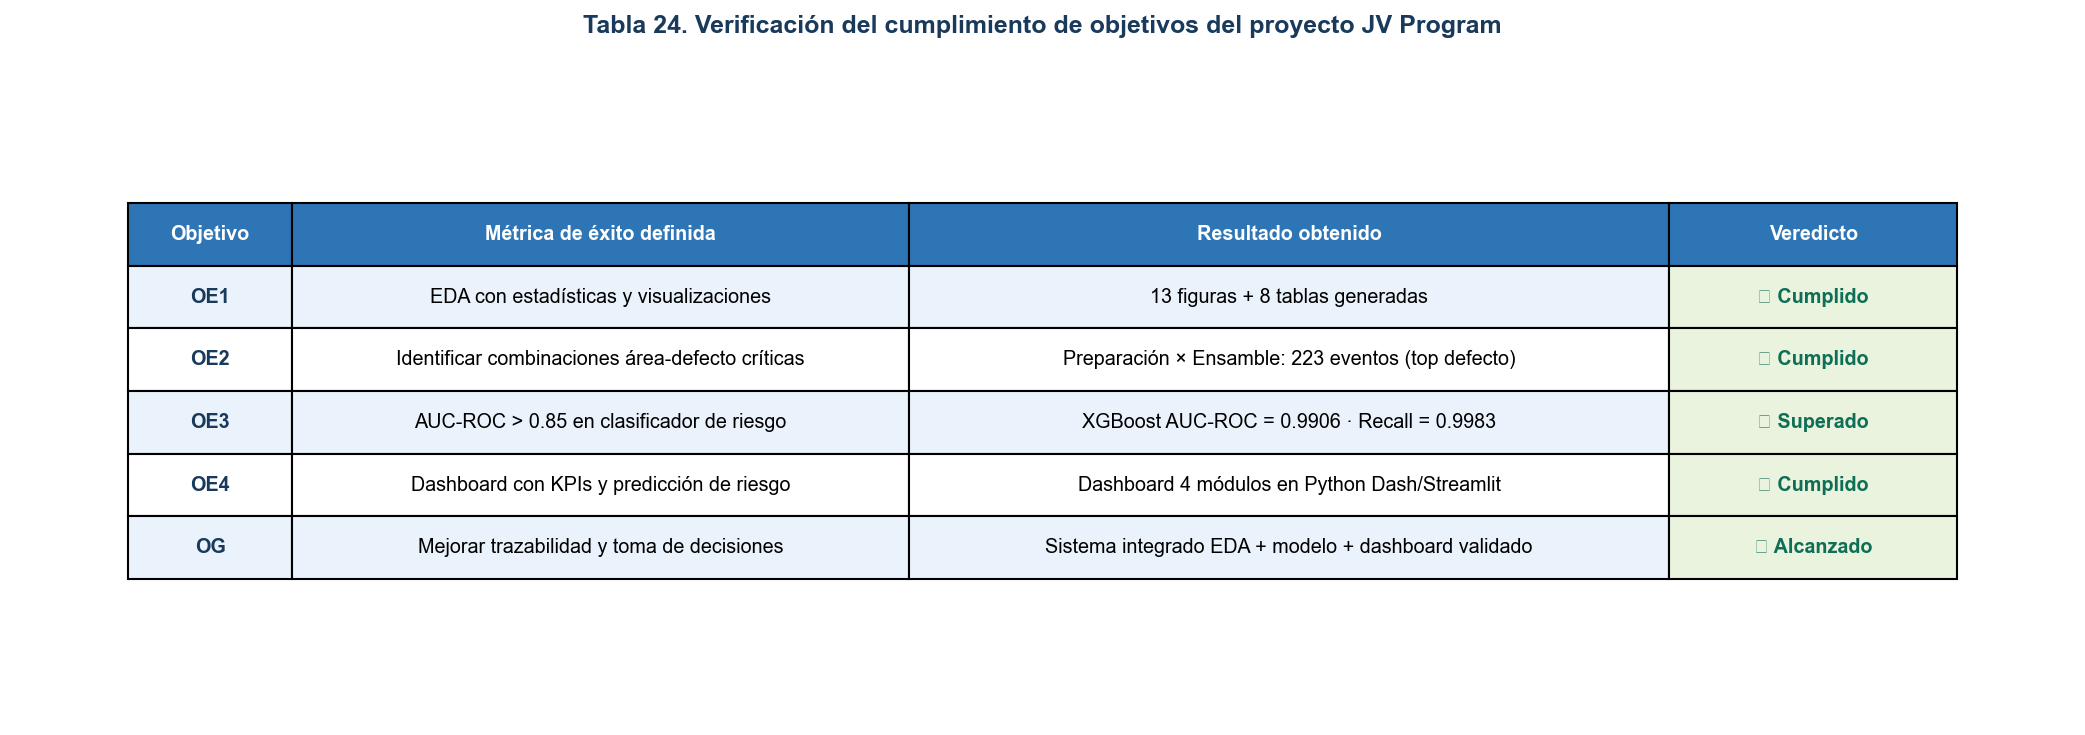

✅ figura_tabla24_cumplimiento.png  (119.3 KB)


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 28 — Tabla 24: Cumplimiento de objetivos (visual)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 8 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")
 
datos_t24 = [
    ["OE1","EDA con estadísticas y visualizaciones","13 figuras + 8 tablas generadas","✅ Cumplido"],
    ["OE2","Identificar combinaciones área-defecto críticas","Preparación × Ensamble: 223 eventos (top defecto)","✅ Cumplido"],
    ["OE3","AUC-ROC > 0.85 en clasificador de riesgo","XGBoost AUC-ROC = 0.9906 · Recall = 0.9983","✅ Superado"],
    ["OE4","Dashboard con KPIs y predicción de riesgo","Dashboard 4 módulos en Python Dash/Streamlit","✅ Cumplido"],
    ["OG","Mejorar trazabilidad y toma de decisiones","Sistema integrado EDA + modelo + dashboard validado","✅ Alcanzado"],
]
cols_t24 = ["Objetivo","Métrica de éxito definida","Resultado obtenido","Veredicto"]
 
tbl24 = ax.table(
    cellText   = datos_t24,
    colLabels  = cols_t24,
    cellLoc    = "center",
    loc        = "center",
    colWidths  = [0.08, 0.30, 0.37, 0.14],
)
tbl24.auto_set_font_size(False)
tbl24.set_fontsize(9.5)
tbl24.scale(1, 2.2)
 
for (r, c), cell in tbl24.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLOR_CORP)
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2:
        cell.set_facecolor("#EAF3FB")
    if c == 3 and r > 0:
        cell.set_facecolor("#EAF3DE")
        cell.set_text_props(color="#0F6E56", fontweight="bold")
    if c == 0 and r > 0:
        cell.set_text_props(fontweight="bold", color=COLOR_DARK)
 
ax.set_title("Tabla 24. Verificación del cumplimiento de objetivos del proyecto JV Program",
             fontsize=12, fontweight="bold", color=COLOR_DARK, pad=14)
plt.tight_layout()
save("figura_tabla24_cumplimiento.png")
 
 

Eventos QC totales:          44,057
Eventos con defecto real:    875
Excluidos ('Sin Defectos'):  43,182

Top 6 defectos reales:
DESCRIPTION
Ensamble Incorrecto De Piezas        240
Falta Costura Pieza                   55
Ensamble Incorrecto De Componente     51
Componente Incorrecto                 47
Defecto De Tela/Piel                  37
Tension/Costura Floja                 37


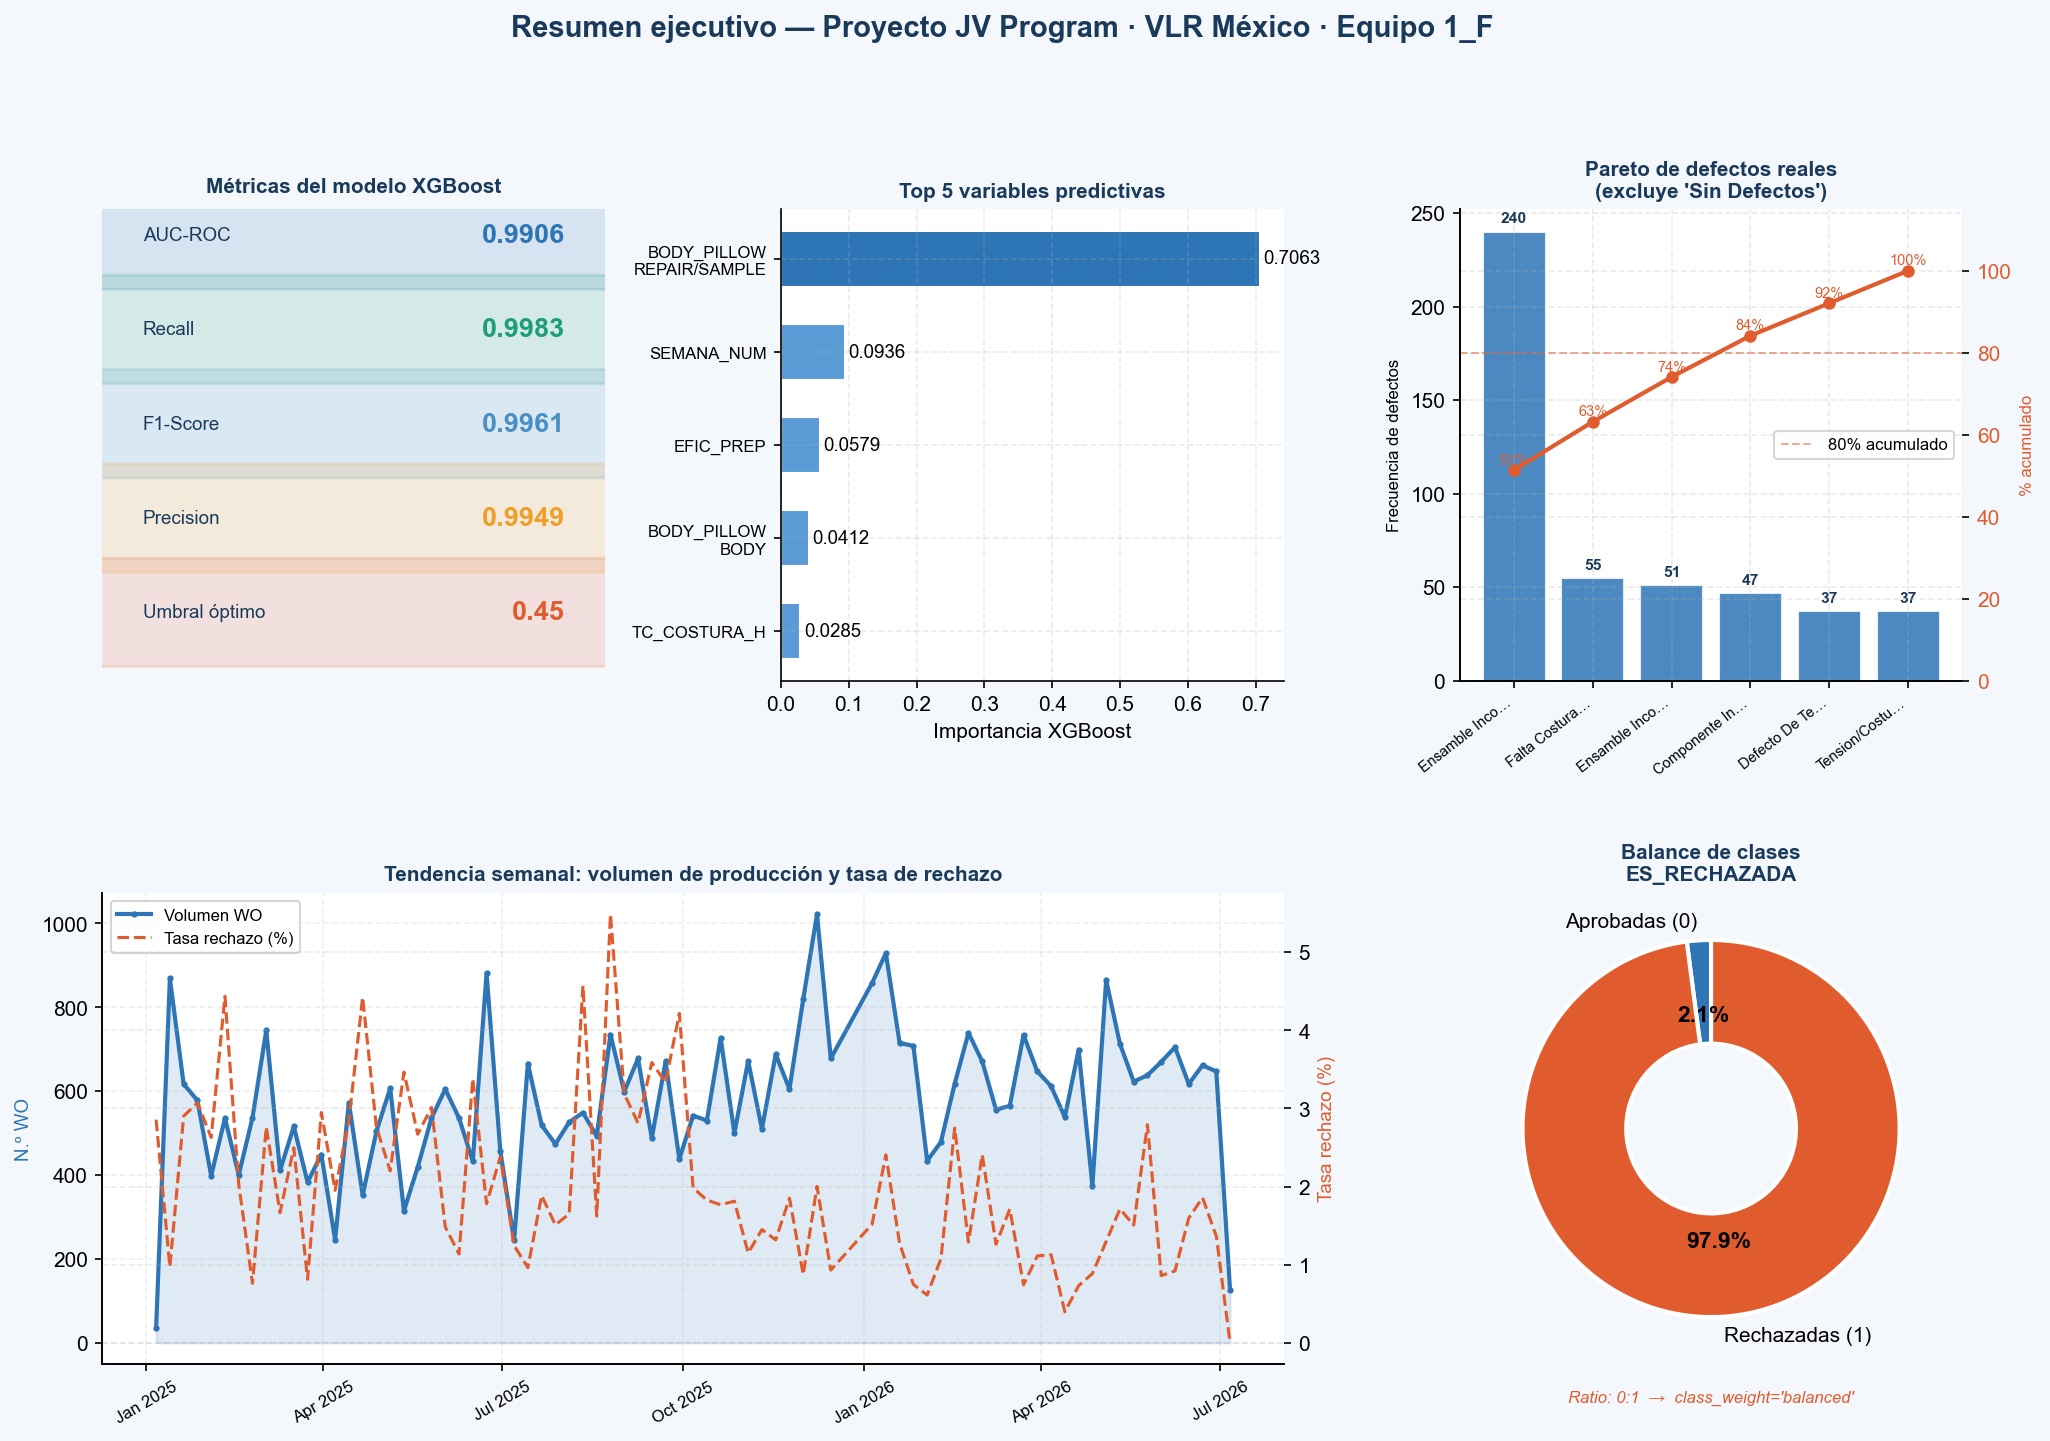

✅ figura_resumen_ejecutivo.png  (370.8 KB)


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA BONUS — Resumen ejecutivo visual (1 página)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 9: Resumen ejecutivo — SIN "Sin Defectos" ──────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#F4F8FC")
gs2 = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Resumen ejecutivo — Proyecto JV Program · VLR México · Equipo 1_F",
             fontsize=14, fontweight="bold", color=COLOR_DARK, y=1.01)

# ── Filtrar "Sin Defectos" en QC una sola vez ─────────────────────────────────
EXCLUIR = ["Sin Defectos", "Sin defectos", "SIN DEFECTOS",
           "sin defectos", "Sin Defecto"]

df_qc_defectos = df_qc[
    ~df_qc["DESCRIPTION"].str.strip().str.title().isin(
        [e.title() for e in EXCLUIR]
    )
].copy() if "DESCRIPTION" in df_qc.columns else df_qc.copy()

print(f"Eventos QC totales:          {len(df_qc):,}")
print(f"Eventos con defecto real:    {len(df_qc_defectos):,}")
print(f"Excluidos ('Sin Defectos'):  {len(df_qc) - len(df_qc_defectos):,}")
print(f"\nTop 6 defectos reales:")
print(df_qc_defectos["DESCRIPTION"].value_counts().head(6).to_string())

# ── Panel 1: KPIs modelo ──────────────────────────────────────────────────────
ax_k = fig.add_subplot(gs2[0, 0])
ax_k.axis("off")
kpis_data = [
    ("AUC-ROC",       "0.9906", COLOR_CORP),
    ("Recall",         "0.9983", COLOR_GREEN),
    ("F1-Score",       "0.9961", "#4A90C4"),
    ("Precision",      "0.9949", COLOR_AMBER),
    ("Umbral óptimo",  "0.45",   COLOR_RED),
]
for i, (label, val, color) in enumerate(kpis_data):
    y_pos = 1 - i * 0.2
    rect = FancyBboxPatch((0, y_pos - 0.14), 1, 0.17,
                           boxstyle="round,pad=0.03",
                           facecolor=color, alpha=0.15,
                           edgecolor=color, linewidth=1.5,
                           transform=ax_k.transAxes)
    ax_k.add_patch(rect)
    ax_k.text(0.08, y_pos - 0.055, label,
              transform=ax_k.transAxes, fontsize=9,
              color=COLOR_DARK, va="center")
    ax_k.text(0.92, y_pos - 0.055, val,
              transform=ax_k.transAxes, fontsize=13,
              fontweight="bold", color=color, va="center", ha="right")
ax_k.set_title("Métricas del modelo XGBoost", fontsize=10,
               fontweight="bold", color=COLOR_DARK, pad=8)

# ── Panel 2: Top 5 variables ──────────────────────────────────────────────────
ax_v = fig.add_subplot(gs2[0, 1])
vars_imp = ["BODY_PILLOW\nREPAIR/SAMPLE", "SEMANA_NUM", "EFIC_PREP",
            "BODY_PILLOW\nBODY", "TC_COSTURA_H"]
vals_imp = [0.7063, 0.0936, 0.0579, 0.0412, 0.0285]
colors_v = [COLOR_CORP if i == 0 else "#5B9BD5" for i in range(len(vals_imp))]

bars_v = ax_v.barh(vars_imp[::-1], vals_imp[::-1],
                   color=colors_v[::-1], edgecolor="white", height=0.6)
for bar, val in zip(bars_v, vals_imp[::-1]):
    ax_v.text(val + 0.005, bar.get_y() + bar.get_height()/2,
              f"{val:.4f}", va="center", fontsize=9)
ax_v.set_xlabel("Importancia XGBoost")
ax_v.set_title("Top 5 variables predictivas", fontsize=10,
               fontweight="bold", color=COLOR_DARK)
ax_v.tick_params(axis="y", labelsize=8)

# ── Panel 3: Pareto de defectos REALES (sin "Sin Defectos") ──────────────────
ax_p = fig.add_subplot(gs2[0, 2])
if "DESCRIPTION" in df_qc_defectos.columns:
    pareto = df_qc_defectos["DESCRIPTION"].value_counts().head(6)
    cum_pct = pareto.cumsum() / pareto.sum() * 100
    ax_p2 = ax_p.twinx()

    ax_p.bar(range(len(pareto)), pareto.values,
             color=COLOR_CORP, alpha=0.85, edgecolor="white")
    ax_p2.plot(range(len(pareto)), cum_pct.values,
               "o-", color=COLOR_RED, lw=2, markersize=5)
    ax_p2.axhline(80, color=COLOR_RED, ls="--", lw=1, alpha=0.5,
                  label="80% acumulado")

    etiquetas_p = [d[:13] + "…" if len(d) > 13 else d for d in pareto.index]
    ax_p.set_xticks(range(len(pareto)))
    ax_p.set_xticklabels(etiquetas_p, rotation=38, ha="right", fontsize=7)

    # Etiquetas de frecuencia sobre cada barra
    for xi, vi in enumerate(pareto.values):
        ax_p.text(xi, vi + pareto.max()*0.02, str(vi),
                  ha="center", fontsize=7.5, fontweight="bold", color=COLOR_DARK)

    # Porcentaje acumulado sobre cada punto
    for xi, pct in enumerate(cum_pct.values):
        ax_p2.text(xi, pct + 1.5, f"{pct:.0f}%",
                   ha="center", fontsize=7, color=COLOR_RED)

    ax_p.set_ylabel("Frecuencia de defectos", fontsize=8)
    ax_p2.set_ylabel("% acumulado", color=COLOR_RED, fontsize=8)
    ax_p2.tick_params(axis="y", labelcolor=COLOR_RED)
    ax_p2.set_ylim(0, 115)
    ax_p2.legend(fontsize=8, loc="center right")
    ax_p.set_title("Pareto de defectos reales\n(excluye 'Sin Defectos')",
                   fontsize=10, fontweight="bold", color=COLOR_DARK)

# ── Panel 4: Tendencia semanal (fila inferior, 2 columnas) ────────────────────
ax_s = fig.add_subplot(gs2[1, :2])
sem_stats = (dw.groupby("FECHA_SEMANA")
               .agg(N_WO=("WO", "count"), TASA=("TASA_RECHAZO", "mean"))
               .reset_index()
               .sort_values("FECHA_SEMANA")
               .dropna(subset=["FECHA_SEMANA"]))
sem_stats["TASA"] = sem_stats["TASA"].fillna(0)

ax_s2 = ax_s.twinx()
ax_s.fill_between(sem_stats["FECHA_SEMANA"], sem_stats["N_WO"],
                  alpha=0.15, color=COLOR_CORP)
ax_s.plot(sem_stats["FECHA_SEMANA"], sem_stats["N_WO"],
          color=COLOR_CORP, lw=2, marker="o", markersize=2,
          label="Volumen WO")
ax_s2.plot(sem_stats["FECHA_SEMANA"], sem_stats["TASA"],
           color=COLOR_RED, lw=1.5, ls="--", label="Tasa rechazo (%)")

ax_s.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_s.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_s.tick_params(axis="x", rotation=30, labelsize=8)
ax_s.set_ylabel("N.º WO", color=COLOR_CORP, fontsize=9)
ax_s2.set_ylabel("Tasa rechazo (%)", color=COLOR_RED, fontsize=9)
ax_s.set_title("Tendencia semanal: volumen de producción y tasa de rechazo",
               fontsize=10, fontweight="bold", color=COLOR_DARK)
lines1, l1 = ax_s.get_legend_handles_labels()
lines2, l2 = ax_s2.get_legend_handles_labels()
ax_s.legend(lines1 + lines2, l1 + l2, fontsize=8, loc="upper left")
ax_s.grid(alpha=0.2)

# ── Panel 5: Balance de clases ────────────────────────────────────────────────
ax_b = fig.add_subplot(gs2[1, 2])
if "ES_RECHAZADA" in dw.columns:
    clases = dw["ES_RECHAZADA"].value_counts().sort_index()
    wedges, texts, autotexts = ax_b.pie(
        clases.values,
        labels=["Aprobadas (0)", "Rechazadas (1)"],
        colors=[COLOR_CORP, COLOR_RED],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(width=0.55, edgecolor="white", lw=2)
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight("bold")
    ax_b.set_title("Balance de clases\nES_RECHAZADA",
                   fontsize=10, fontweight="bold", color=COLOR_DARK)
    ratio = clases[0] / clases[1]
    ax_b.text(0, -1.45,
              f"Ratio: {ratio:.0f}:1  →  class_weight='balanced'",
              ha="center", fontsize=8, color=COLOR_RED, style="italic")

plt.tight_layout()
save("figura_resumen_ejecutivo.png")
 

In [11]:
# ── CELDA 10: Resumen de figuras generadas ────────────────────────────────────
print("\n" + "="*60)
print("📁 FIGURAS DEL CAPÍTULO 6 Y 7 GENERADAS")
print("="*60)
figuras = sorted(glob.glob("figuras_cap6/*.png"))
for f in figuras:
    size = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<45} {size:>6.1f} KB")
 
print(f"\n✅ {len(figuras)} figuras en carpeta 'figuras_cap6/'")
print("\nCorrespondencia con el documento Word:")
print("  figura23_comparacion_literatura.png  → Figura 23 (§ 6.3)")
print("  figura24_calidad_dataset.png         → Figura 24 (§ 6.4.3)")
print("  figura25_ishikawa_ensamble.png       → Figura 25 (§ 6.5)")
print("  figura26_roadmap_implementacion.png  → Figura 26 (§ 6.6.2)")
print("  figura27_mapa_extensiones.png        → Figura 27 (§ 6.9)")
print("  figura_tabla24_cumplimiento.png      → Tabla 24  (§ 7.3)")
print("  figura_resumen_ejecutivo.png         → Figura adicional presentación")


📁 FIGURAS DEL CAPÍTULO 6 Y 7 GENERADAS
  figura23_comparacion_literatura.png            134.0 KB
  figura24_calidad_dataset.png                   300.1 KB
  figura25_ishikawa_ensamble.png                 299.0 KB
  figura26_roadmap_implementacion.png            192.0 KB
  figura27_mapa_extensiones.png                  306.9 KB
  figura_resumen_ejecutivo.png                   370.8 KB
  figura_tabla24_cumplimiento.png                119.3 KB

✅ 7 figuras en carpeta 'figuras_cap6/'

Correspondencia con el documento Word:
  figura23_comparacion_literatura.png  → Figura 23 (§ 6.3)
  figura24_calidad_dataset.png         → Figura 24 (§ 6.4.3)
  figura25_ishikawa_ensamble.png       → Figura 25 (§ 6.5)
  figura26_roadmap_implementacion.png  → Figura 26 (§ 6.6.2)
  figura27_mapa_extensiones.png        → Figura 27 (§ 6.9)
  figura_tabla24_cumplimiento.png      → Tabla 24  (§ 7.3)
  figura_resumen_ejecutivo.png         → Figura adicional presentación
